# 06 · Coherency Gap

**Purpose:** Quantify the *incoherence* of pre-reconciliation forecasts — how far the sum of unit-level predictions drifts from the independently-trained aggregate forecast.

```
gap(t) = aggregate_forecast(t)  −  sum_of_unit_forecasts(t)
```

A non-zero gap is the gap that hierarchical reconciliation in nb07 will close. Reporting it before reconciliation gives the paper its "before" number to contrast against the "after" (≈ machine epsilon by construction of MinT).

**Inputs (from nb05):**
- `forecasts_individual_{dataset}.parquet`
- `forecasts_aggregate_{dataset}.parquet`

**Outputs (to `OUTPUT_DIR` and `results/figures/`):**
- `coherency_gap_{dataset}.parquet` — full per-timestamp gap rows
- `coherency_summary_{dataset}.csv` — summary by (approach, model)
- Three figures (gap by approach×model, gap time-series, gap by hour)

**Switch dataset:** change `DATASET` in the Configuration cell — everything else adapts via `config/settings.py`.

**Pipeline flow:** nb05 → **nb06** → nb07_reconcile (nb07 does **not** read the gap parquet — it recomputes its own *post*-reconciliation coherency check. nb06 is standalone analysis.)

## 1. Setup

Resolve the project root and import everything we need.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

_root = os.path.abspath('')
for _ in range(6):
    if os.path.isdir(os.path.join(_root, 'config')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(_root)

import config.settings as _settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(f'Root: {_root}')

Root: /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast


## 2. Configuration

`DATASET` controls which forecasts we analyse. `OUTPUT_DIR` (data) and `FIG_DIR` (paper figures) are resolved from `config/settings.py` — figures are saved to **both** so the dataset folder is self-contained for browsing while the paper directory stays the canonical source of truth.

In [2]:
# ── CONFIG — change DATASET here ──────────────────────────────────────────────
DATASET = 'chp'    # 'chp' or 'lcl'

# Load the matching config block
cfg = _settings.CHP if DATASET == 'chp' else _settings.LCL

ID_COL     = cfg['ID_COL']
OUTPUT_DIR = os.path.join(_root, cfg['OUTPUT_DIR'])
FIG_DIR    = os.path.join(_root, 'results', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Diagnostic plot draw — change to inspect different draws
PLOT_DRAW = 0

print(f'Dataset    : {DATASET}')
print(f'ID_COL     : {ID_COL}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'FIG_DIR    : {FIG_DIR}')
print(f'PLOT_DRAW  : {PLOT_DRAW}')
ID_COL       = cfg['ID_COL']                         # 'LCLid'
DEMAND_COL   = cfg['DEMAND_COL']                     # 'kWh'
OUTPUT_DIR   = os.path.join(_root, cfg['OUTPUT_DIR'])  # 'data/output_lcl/'
SAMPLE_SIZE  = cfg['SAMPLE_SIZE']
N_DRAWS      = 10 # cfg['N_DRAWS']
TRAIN_MONTHS = cfg['TRAIN_MONTHS']
VAL_MONTHS   = cfg['VAL_MONTHS']

Dataset    : chp
ID_COL     : chp_id
OUTPUT_DIR : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/
FIG_DIR    : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures
PLOT_DRAW  : 0


## 3. Load forecasts from notebook 05

`forecasts_aggregate_{dataset}.parquet` may contain `Naive24` / `Naive168` rows alongside the trained `LR` / `LGBM` rows (added by the optimized nb05). We keep them — section 5 computes a baseline naive coherency gap from them.

In [3]:
# ── Load forecast parquets from nb05 ─────────────────────────────────────────
ind_path = os.path.join(OUTPUT_DIR, f'forecasts_individual_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
agg_path = os.path.join(OUTPUT_DIR, f'forecasts_aggregate_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet')

assert os.path.exists(ind_path), (
    f'Missing: {ind_path}\nRun 05_forecast_{DATASET}.ipynb first.'
)
assert os.path.exists(agg_path), (
    f'Missing: {agg_path}\nRun 05_forecast_{DATASET}.ipynb first.'
)

ind = pd.read_parquet(ind_path)
agg = pd.read_parquet(agg_path)
ind['timestamp'] = pd.to_datetime(ind['timestamp'])
agg['timestamp'] = pd.to_datetime(agg['timestamp'])

trained_models = sorted([m for m in agg['model'].unique()
                         if m not in ('Naive24', 'Naive168')])
naive_models   = sorted([m for m in agg['model'].unique()
                         if m in ('Naive24', 'Naive168')])

print(f'Individual : {ind.shape}  approaches: {sorted(ind["approach"].unique())}')
print(f'Aggregate  : {agg.shape}')
print(f'  trained models: {trained_models}')
print(f'  naive models  : {naive_models}')
print(f'N draws    : {ind["draw"].nunique()}')

Individual : (13392000, 7)  approaches: ['global', 'local']
Aggregate  : (267840, 6)
  trained models: ['LGBM', 'LR']
  naive models  : ['Naive168', 'Naive24']
N draws    : 10


## 4. Compute coherency gap — trained models

For each (draw, trained model, approach) combination:

1. **bottom-up sum** = `Σ_units y_pred(t)` — the implied aggregate from independent unit forecasts
2. **aggregate forecast** = the directly-trained top-level prediction
3. **gap(t)** = aggregate_forecast(t) − bottom_up_sum(t)

A small assertion checks that `Σ_units y_true` matches the aggregate's `y_true` — they *must* be identical by construction (both are the same physical sum of demand). A divergence here would point to a bug upstream in nb05.

In [4]:
# ── Compute coherency gap for trained (LR / LGBM) models ─────────────────────
gap_records = []
y_true_consistency_max_diff = 0.0  # accumulate max |Σy_true_unit - y_true_agg|

# Only iterate over models that exist in both ind and agg
common_models = sorted(set(ind['model'].unique()) & set(trained_models))

for (draw, model, approach), grp in ind.groupby(['draw', 'model', 'approach']):
    if model not in common_models:
        continue

    bu = (
        grp.groupby('timestamp')
        .agg(bottom_up_sum=('y_pred', 'sum'),
             y_true_sum   =('y_true', 'sum'))
        .reset_index()
    )
    ag_sub = (
        agg[(agg['draw'] == draw) & (agg['model'] == model)]
        [['timestamp', 'y_pred', 'y_true']]
        .rename(columns={'y_pred': 'aggregate_pred', 'y_true': 'y_true_agg'})
    )
    if ag_sub.empty:
        continue

    merged = bu.merge(ag_sub, on='timestamp', how='inner')
    if merged.empty:
        continue

    # Sanity check: Σ unit y_true should equal aggregate y_true
    diff = (merged['y_true_sum'] - merged['y_true_agg']).abs().max()
    if pd.notna(diff):
        y_true_consistency_max_diff = max(y_true_consistency_max_diff, float(diff))

    merged['gap']     = merged['aggregate_pred'] - merged['bottom_up_sum']
    merged['gap_abs'] = merged['gap'].abs()
    merged['gap_pct'] = (
        merged['gap_abs']
        / merged['y_true_agg'].abs().replace(0, np.nan) * 100
    )
    merged['draw']     = draw
    merged['model']    = model
    merged['approach'] = approach
    gap_records.append(merged)

coherency_gap = pd.concat(gap_records, ignore_index=True)
print(f'Coherency gap rows (trained models): {len(coherency_gap):,}')
print(f'y_true consistency check: max |Σ_units y_true − aggregate y_true| = '
      f'{y_true_consistency_max_diff:.2e}')
assert y_true_consistency_max_diff < 1e-3, (
    'Aggregate y_true diverges from Σ unit y_true — check nb05 outputs.'
)
print('  ✅ y_true is consistent between individual and aggregate forecasts.')

Coherency gap rows (trained models): 267,840
y_true consistency check: max |Σ_units y_true − aggregate y_true| = 0.00e+00
  ✅ y_true is consistent between individual and aggregate forecasts.


## 5. Naive baseline coherency gap — null-control check

The aggregate parquet contains `Naive24` and `Naive168` rows (lag-24 / lag-168 of the *aggregate* truth). Their natural bottom-up counterpart is the **lag-shifted sum of unit truths**: for each timestamp `t`, `Σ_units y_true(t − lag)`.

**Important — this is a sanity check, not a "naive baseline number" for the paper.** The two quantities are mathematically identical:

```
Naive aggregate forecast:  y_true_agg(t-lag)         = Σ_units y_true(t-lag)
Naive bottom-up sum:       Σ_units y_true(t-lag)
```

So the gap is **≈ 0 by construction**. Computing it gives a useful null-control: any non-trivial residual here would point to inconsistent NaN handling or timestamp alignment between nb05's unit-level and aggregate-level shifts. A clean ≈ 0 confirms the pipeline plumbing is correct before we trust the LR/LGBM gap numbers.

The naive rows are appended to `coherency_gap` under `approach='naive'` so they're stored separately from `local`/`global` and easy to filter out of the headline summary.


In [5]:
# ── Naive baseline coherency gap ──────────────────────────────────────────────
# Bottom-up: Σ_units y_true(t - lag)
# Aggregate: Naive{lag} row from agg, which is y_true_agg(t - lag)
# Same structure as the trained-model gap, but with `approach='naive'`.

naive_gap_records = []

for naive_model, lag in [('Naive24', 24), ('Naive168', 168)]:
    if naive_model not in agg['model'].unique():
        continue

    for draw in sorted(ind['draw'].unique()):
        # One representative (approach, model) gives us all unit y_true series
        ind_d = ind[
            (ind['draw'] == draw) &
            (ind['approach'] == 'global') &
            (ind['model'] == 'LGBM')
        ][[ID_COL, 'timestamp', 'y_true']].copy()
        if ind_d.empty:
            continue

        # Shift each unit's y_true by `lag` hours, then sum across units
        ind_d = ind_d.sort_values([ID_COL, 'timestamp'])
        ind_d['y_naive'] = (
            ind_d.groupby(ID_COL)['y_true'].shift(lag)
        )
        bu = (
            ind_d.dropna(subset=['y_naive'])
            .groupby('timestamp')
            .agg(bottom_up_sum=('y_naive', 'sum'),
                 y_true_sum   =('y_true', 'sum'))
            .reset_index()
        )

        ag_sub = (
            agg[(agg['draw'] == draw) & (agg['model'] == naive_model)]
            [['timestamp', 'y_pred', 'y_true']]
            .rename(columns={'y_pred': 'aggregate_pred', 'y_true': 'y_true_agg'})
        )
        merged = bu.merge(ag_sub, on='timestamp', how='inner')
        if merged.empty:
            continue

        merged['gap']     = merged['aggregate_pred'] - merged['bottom_up_sum']
        merged['gap_abs'] = merged['gap'].abs()
        merged['gap_pct'] = (
            merged['gap_abs']
            / merged['y_true_agg'].abs().replace(0, np.nan) * 100
        )
        merged['draw']     = draw
        merged['model']    = naive_model
        merged['approach'] = 'naive'
        naive_gap_records.append(merged)

if naive_gap_records:
    naive_gap = pd.concat(naive_gap_records, ignore_index=True)
    coherency_gap = pd.concat([coherency_gap, naive_gap], ignore_index=True)
    print(f'Naive baseline gap rows added: {len(naive_gap):,}')
    print(f'Combined coherency gap: {coherency_gap.shape}')
else:
    print('No naive baseline rows found in aggregate parquet — skipping.')
    print('(This is expected for the older non-optimized nb05 output.)')

Naive baseline gap rows added: 132,000
Combined coherency gap: (399840, 11)


## 6. Summary table

Group the per-timestamp gap by `(approach, model)` and report:

- `gap_mean` — signed mean gap (positive ⇒ aggregate forecast tends to *overshoot* the bottom-up sum).
- `gap_abs_mean` — mean **absolute** gap in native demand units (the headline number for the paper).
- `gap_pct_mean` — gap as % of true aggregate demand (scale-free, comparable across datasets).
- `gap_max` — worst single-timestamp absolute gap.

Then a short reduction comparison: **local → global** for each model. Global pooling shares structure across units, so its bottom-up sum should already be more coherent with the aggregate forecast than per-unit local fits.

In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
gap_summary = (
    coherency_gap
    .groupby(['approach', 'model'])
    .agg(
        gap_mean     = ('gap',     'mean'),
        gap_std      = ('gap',     'std'),
        gap_abs_mean = ('gap_abs', 'mean'),
        gap_pct_mean = ('gap_pct', 'mean'),
        gap_max      = ('gap_abs', 'max'),
    )
    .round(4)
)

print('=' * 70)
print(f'COHERENCY GAP SUMMARY — {DATASET.upper()}')
print('=' * 70)
print('  gap_mean     = mean signed gap (+ = aggregate > bottom-up)')
print('  gap_abs_mean = mean absolute gap (native demand units)')
print('  gap_pct_mean = gap as % of true aggregate demand')
print('  gap_max      = worst single-timestamp absolute gap')
print()
print(gap_summary.to_string())

# Local → global reduction (trained models only)
print('\nGap reduction local → global (trained models):')
for model in trained_models:
    try:
        loc_g = gap_summary.loc[('local',  model), 'gap_abs_mean']
        glb_g = gap_summary.loc[('global', model), 'gap_abs_mean']
        red   = (loc_g - glb_g) / loc_g * 100 if loc_g > 0 else np.nan
        print(f'  {model:6s}: {loc_g:.4f} → {glb_g:.4f}  ({red:+.1f}% reduction)')
    except KeyError:
        pass

# Null-control check (gap should be ~0 by construction)
if 'naive' in coherency_gap['approach'].unique():
    print('\nNull-control check — naive gap should be ~0 by construction:')
    for nm in ['Naive24', 'Naive168']:
        try:
            naive_g = gap_summary.loc[('naive', nm), 'gap_abs_mean']
            print(f'  {nm:8s}: {naive_g:.4f}')
        except KeyError:
            pass
    for model in trained_models:
        try:
            glb_g = gap_summary.loc[('global', model), 'gap_abs_mean']
            print(f'  global {model:5s}: {glb_g:.4f}')
        except KeyError:
            pass

COHERENCY GAP SUMMARY — CHP
  gap_mean     = mean signed gap (+ = aggregate > bottom-up)
  gap_abs_mean = mean absolute gap (native demand units)
  gap_pct_mean = gap as % of true aggregate demand
  gap_max      = worst single-timestamp absolute gap

                   gap_mean  gap_std  gap_abs_mean  gap_pct_mean  gap_max
approach model                                                           
global   LGBM        2.0015  14.3371       11.0954        4.4975  69.4503
         LR          3.2797  10.4560        8.4438        3.4988  43.1654
local    LGBM       -1.2872  17.1414       13.7313        5.4137  84.7636
         LR          0.2207  13.2338       10.4483        4.1870  64.2908
naive    Naive168    0.0000   0.0000        0.0000        0.0000   0.0000
         Naive24     0.0000   0.0000        0.0000        0.0000   0.0000

Gap reduction local → global (trained models):
  LGBM  : 13.7313 → 11.0954  (+19.2% reduction)
  LR    : 10.4483 → 8.4438  (+19.2% reduction)

Null-control 

## 7. Save outputs

Parquet (full per-timestamp rows) and CSV (summary) go to `OUTPUT_DIR`. nb07 doesn't read these, but having them on disk lets you compare datasets later or pull numbers into the paper without rerunning.

In [7]:
# ── Save outputs ──────────────────────────────────────────────────────────────
gap_path = os.path.join(OUTPUT_DIR, f'coherency_gap_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
sum_path = os.path.join(OUTPUT_DIR, f'coherency_summary_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.csv')
coherency_gap.to_parquet(gap_path, index=False)
gap_summary.to_csv(sum_path)
print(f'Saved: {gap_path}  ({coherency_gap.shape})')
print(f'Saved: {sum_path}')

Saved: /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/coherency_gap_chp.50.10.parquet  ((399840, 11))
Saved: /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/coherency_summary_chp.50.10.csv


## 8. Figure 1 — Mean absolute gap by (approach × model)

Bar chart for the summary table. Every figure in this notebook is saved to **both** `OUTPUT_DIR` (for quick browsing alongside the data) and `results/figures/` (the paper-figure directory used by nb08).

Saved -> data/output/fig_gap_bar_chp.png
Saved -> results/figures/fig_gap_bar_chp.png


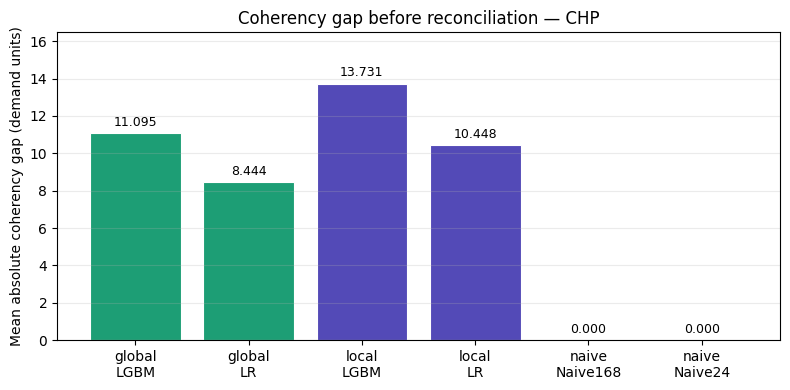

In [8]:
# ── Helper: save a figure to both OUTPUT_DIR and results/figures/ ────────────
def save_fig(fig, basename):
    p1 = os.path.join(OUTPUT_DIR, f'{basename}_{DATASET}.png')
    p2 = os.path.join(FIG_DIR,    f'{basename}_{DATASET}.png')
    fig.savefig(p1, dpi=150, bbox_inches='tight')
    fig.savefig(p2, dpi=150, bbox_inches='tight')
    print(f'Saved -> {os.path.relpath(p1, _root)}')
    print(f'Saved -> {os.path.relpath(p2, _root)}')

# ── Fig 1: Bar chart — mean absolute gap by (approach × model) ───────────────
plot_df = gap_summary['gap_abs_mean'].reset_index()
labels  = [f'{r.approach}\n{r.model}' for _, r in plot_df.iterrows()]

# Distinct colour per approach
APPROACH_COLOR = {'local': '#534AB7', 'global': '#1D9E75', 'naive': '#9C9C9C'}
colors = [APPROACH_COLOR.get(a, '#888888') for a in plot_df['approach']]

fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(plot_df)), 4))
bars = ax.bar(range(len(plot_df)), plot_df['gap_abs_mean'],
              color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Mean absolute coherency gap (demand units)')
ax.set_title(f'Coherency gap before reconciliation — {DATASET.upper()}')
ax.set_ylim(0, plot_df['gap_abs_mean'].max() * 1.2)
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
save_fig(fig, 'fig_gap_bar')
plt.show()

## 9. Figure 2 — Gap time series for one draw

For `PLOT_DRAW`, **global LGBM**: the bottom-up sum, the direct aggregate forecast, and the true aggregate over the test period. The lower panel highlights the raw signed gap. Spikes here are the moments reconciliation will smooth out.

Saved -> data/output/fig_gap_ts_chp.png
Saved -> results/figures/fig_gap_ts_chp.png


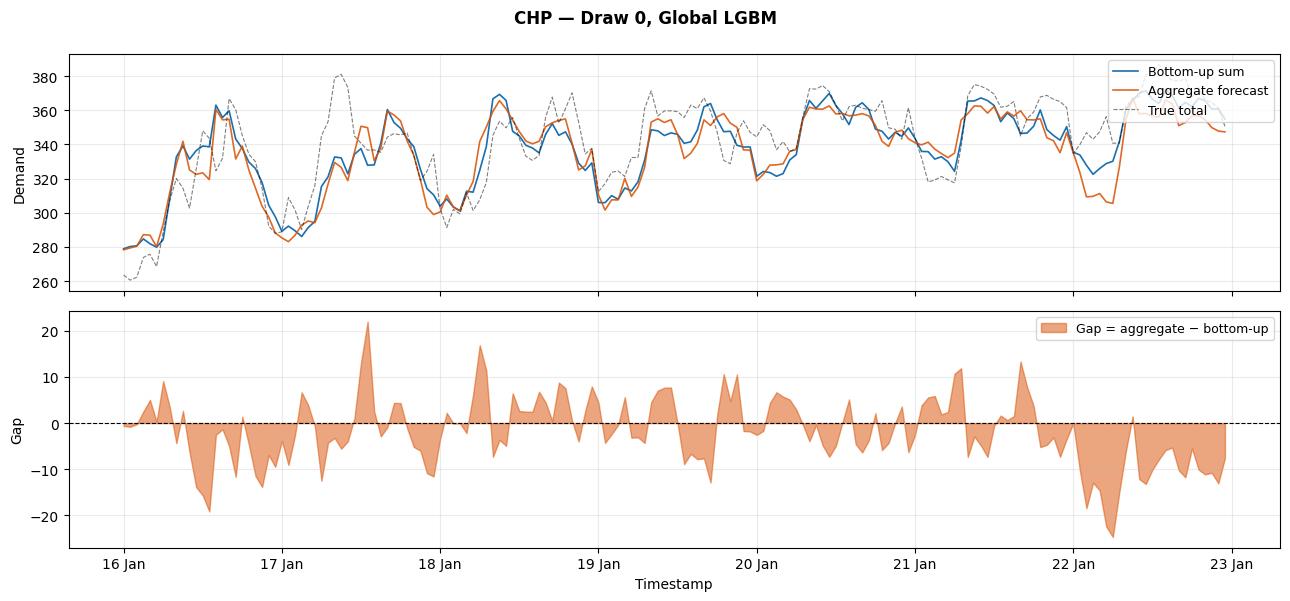

In [9]:
# ── Fig 2: Gap time series — PLOT_DRAW, global LGBM ──────────────────────────
sub = coherency_gap[
    (coherency_gap['draw']     == PLOT_DRAW) &
    (coherency_gap['model']    == 'LGBM') &
    (coherency_gap['approach'] == 'global')
].sort_values('timestamp')

sub['timestamp'] = pd.to_datetime(sub['timestamp'])

# Example: select ISO week 1
sub = sub[sub['timestamp'].dt.isocalendar().week == 3]

if sub.empty:
    print(f'⚠️  No data for draw={PLOT_DRAW}, global, LGBM — skipping fig 2.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.suptitle(f'{DATASET.upper()} — Draw {PLOT_DRAW}, Global LGBM',
                 fontsize=12, fontweight='bold', y=0.995)

    axes[0].plot(sub['timestamp'], sub['bottom_up_sum'],
                 label='Bottom-up sum',      lw=1.2, color='#1a6faf')
    axes[0].plot(sub['timestamp'], sub['aggregate_pred'],
                 label='Aggregate forecast', lw=1.2, color='#d94f00', alpha=0.85)
    axes[0].plot(sub['timestamp'], sub['y_true_agg'],
                 label='True total',         lw=0.8, color='black', alpha=0.5, ls='--')
    axes[0].set_ylabel('Demand')
    axes[0].legend(fontsize=9, loc='upper right')
    axes[0].grid(True, alpha=0.25)

    axes[1].fill_between(sub['timestamp'], sub['gap'],
                         alpha=0.5, color='#d94f00',
                         label='Gap = aggregate − bottom-up')
    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[1].set_ylabel('Gap')
    axes[1].set_xlabel('Timestamp')
    axes[1].legend(fontsize=9, loc='upper right')
    axes[1].grid(True, alpha=0.25)

    axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

    plt.tight_layout()
    save_fig(fig, 'fig_gap_ts')
    plt.show()

## 10. Figure 3 — Gap by hour of day

Aggregating the absolute gap by hour of day reveals whether incoherence concentrates around peak hours (which would be a strong argument for hierarchical reconciliation in operational forecasting). Computed for global LGBM across all draws.

Saved -> data/output/fig_gap_hourly_chp.png
Saved -> results/figures/fig_gap_hourly_chp.png


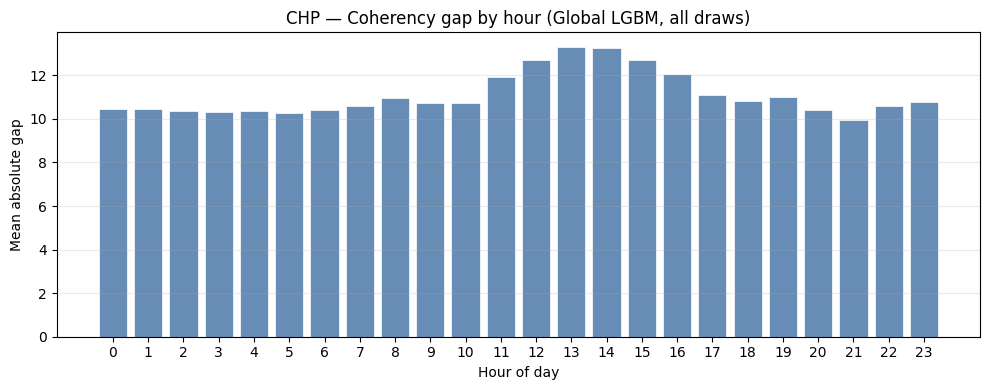

In [10]:
# ── Fig 3: Gap by hour of day — global LGBM, all draws ───────────────────────
hourly_view = coherency_gap[
    (coherency_gap['model']    == 'LGBM') &
    (coherency_gap['approach'] == 'global')
]

if hourly_view.empty:
    print('⚠️  No global LGBM rows — skipping fig 3.')
else:
    hourly = (
        hourly_view
        .assign(hour=lambda d: pd.to_datetime(d['timestamp']).dt.hour)
        .groupby('hour')['gap_abs']
        .mean()
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(hourly.index, hourly.values, color='#4C78A8', alpha=0.85,
           edgecolor='white', linewidth=0.6)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Mean absolute gap')
    ax.set_title(f'{DATASET.upper()} — Coherency gap by hour (Global LGBM, all draws)')
    ax.set_xticks(range(0, 24))
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    save_fig(fig, 'fig_gap_hourly')
    plt.show()

## 11. Findings

Headline numbers for the paper: which (approach × model) combination has the smallest pre-reconciliation gap, and what each global model's gap is in absolute and percentage terms.

In [11]:
# ── Final summary ─────────────────────────────────────────────────────────────
# Smallest-gap combination across the trained models only (naive is for context)
trained_summary = gap_summary.loc[
    gap_summary.index.get_level_values('approach').isin(['local', 'global'])
]
best_row = trained_summary['gap_abs_mean'].idxmin()
best_val = trained_summary['gap_abs_mean'].min()

print('=' * 70)
print(f'FINDINGS — {DATASET.upper()}')
print('=' * 70)
print(f'Smallest gap (trained) : {best_row}  →  {best_val:.4f} demand units')

for model in trained_models:
    try:
        g = gap_summary.loc[('global', model)]
        print(f'Global {model:6s}:  gap = {g["gap_abs_mean"]:.4f}  '
              f'({g["gap_pct_mean"]:.2f}% of true aggregate)')
    except KeyError:
        pass

if 'naive' in coherency_gap['approach'].unique():
    print('\nNull-control (should be ~0 — same shifted unit-truth sum on both sides):')
    for nm in ['Naive24', 'Naive168']:
        try:
            g = gap_summary.loc[('naive', nm)]
            tag = '✅' if g['gap_abs_mean'] < 1e-6 else '⚠️'
            print(f'  {nm:8s}:  gap = {g["gap_abs_mean"]:.2e}  {tag}')
        except KeyError:
            pass

print(f'\n✅  Notebook 06 complete')
print(f'   Data    -> {OUTPUT_DIR}')
print(f'   Figures -> {FIG_DIR}  (and copies in OUTPUT_DIR)')
print(f'   coherency_gap_{DATASET}.parquet is standalone — nb07 recomputes its own '
      f'post-reconciliation check.')
print(f'   To run the other dataset: change DATASET in section 2.')

FINDINGS — CHP
Smallest gap (trained) : ('global', 'LR')  →  8.4438 demand units
Global LGBM  :  gap = 11.0954  (4.50% of true aggregate)
Global LR    :  gap = 8.4438  (3.50% of true aggregate)

Null-control (should be ~0 — same shifted unit-truth sum on both sides):
  Naive24 :  gap = 0.00e+00  ✅
  Naive168:  gap = 0.00e+00  ✅

✅  Notebook 06 complete
   Data    -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/
   Figures -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures  (and copies in OUTPUT_DIR)
   coherency_gap_chp.parquet is standalone — nb07 recomputes its own post-reconciliation check.
   To run the other dataset: change DATASET in section 2.


In [12]:
import os, glob, time

# 1. What did nb05 just save, and when?
print("=== nb05 outputs (LCL) ===")
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*')), key=os.path.getmtime):
    mtime = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(f)))
    print(f"{mtime}  {f}")

=== nb05 outputs (LCL) ===
2026-05-11 00:52:48  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/sensitivity_results_chp.parquet
2026-05-11 00:52:48  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/sensitivity_summary_chp.csv
2026-05-11 00:52:48  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/fig_sensitivity_sample_size_chp.png
2026-05-13 11:16:44  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/metrics_per_unit_chp.parquet
2026-05-14 12:59:22  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_individual_chp.parquet
2026-05-14 12:59:23  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_individual_val_chp.parquet
2026-05-14 12:59:23  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_aggregate_chp.parquet
2026-05-14 12:59:23  /Users/tali

In [17]:
# 2. Does nb06/nb07 load a file with a timestamp matching your just-finished nb05 run?
print("=== files nb06/nb07 will load ===")
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*chp*')), key=os.path.getmtime):
    mtime = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(f)))
    print(f"{mtime}  {f}")

=== files nb06/nb07 will load ===
2026-05-11 00:52:48  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/sensitivity_results_chp.parquet
2026-05-11 00:52:48  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/sensitivity_summary_chp.csv
2026-05-11 00:52:48  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/fig_sensitivity_sample_size_chp.png
2026-05-13 11:16:44  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/metrics_per_unit_chp.parquet
2026-05-14 12:59:22  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_individual_chp.parquet
2026-05-14 12:59:23  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_individual_val_chp.parquet
2026-05-14 12:59:23  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_aggregate_chp.parquet
2026-05-14 12:59:23  /Use

In [18]:
print(f"Current config: SAMPLE_SIZE={SAMPLE_SIZE}  N_DRAWS={N_DRAWS}")
import glob, os, time
expected = os.path.join(OUTPUT_DIR, f'forecasts_aggregate_lcl.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
print(f"Expected path from today's run: {expected}")
print(f"Exists: {os.path.exists(expected)}")
if os.path.exists(expected):
    print(f"Modified: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(expected)))}")

print()
print("All forecasts_aggregate_lcl* files:")
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'chp*'))):
    print(f"  {f}  (modified {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(f)))})")

Current config: SAMPLE_SIZE=50  N_DRAWS=10
Expected path from today's run: /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_aggregate_lcl.50.10.parquet
Exists: False

All forecasts_aggregate_lcl* files:
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/chp_capacity.parquet  (modified 2026-05-26 11:47:30)
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/chp_intraday_forecast.parquet  (modified 2026-05-26 11:47:30)


In [19]:
import glob, os
import pandas as pd
import numpy as np

for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'forecasts_aggregate_chp*.parquet'))):
    try:
        df = pd.read_parquet(f)
        lgbm_mae = df[df['model'] == 'LGBM'].assign(
            ae=lambda x: (x['y_true'] - x['y_pred']).abs()
        ).groupby('draw')['ae'].mean().mean()
        n_draws_in_file = df['draw'].nunique()
        print(f"{os.path.basename(f):45s}  LGBM agg MAE={lgbm_mae:.4f}  n_draws={n_draws_in_file}")
    except Exception as e:
        print(f"{os.path.basename(f):45s}  ERROR: {e}")

forecasts_aggregate_chp.50.10.parquet          LGBM agg MAE=20.1858  n_draws=10
forecasts_aggregate_chp.50.20.parquet          LGBM agg MAE=21.9279  n_draws=20
forecasts_aggregate_chp.50.30.parquet          LGBM agg MAE=21.7476  n_draws=30
forecasts_aggregate_chp.parquet                LGBM agg MAE=21.7476  n_draws=30


In [21]:
import json
with open(os.path.join(OUTPUT_DIR, 'mean_agg_demand_chp.json')) as f:
    mean_agg = json.load(f)
print(mean_agg)

{'per_draw': {'9': 262.3749372759857}, 'mean': 262.3749372759857}
